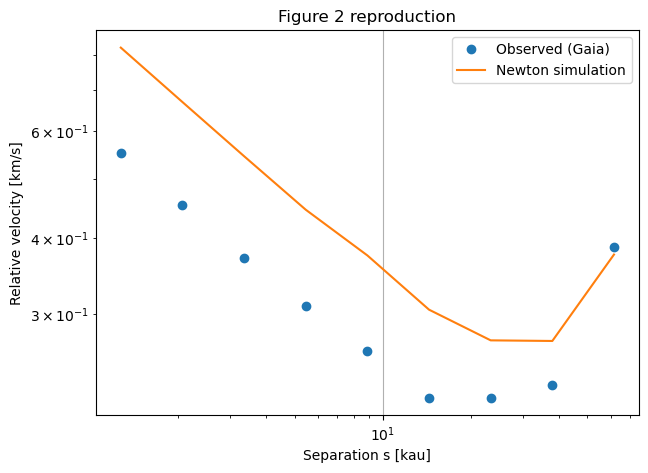

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================
# LOAD FILES
# =============================
df_obs = pd.read_csv("gaia_dr3_MSMS_d200pc.csv")
df_newt = pd.read_csv("Newton_clean_1.csv")

# =============================
# RENAME (same as before)
# =============================
rename_map = {
    "s[kau]": "rp",
    "d1[pc]": "d_A",
    "d2[pc]": "d_B",
    "mu1ra[mas/yr]": "mux_A",
    "mu1dec[mas/yr]": "muy_A",
    "mu2ra[mas/yr]": "mux_B",
    "mu2dec[mas/yr]": "muy_B"
}

df_obs = df_obs.rename(columns=rename_map)
df_newt = df_newt.rename(columns=rename_map)

# =============================
# DISTANCE (mean)
# =============================
df_obs["d"] = (df_obs["d_A"] + df_obs["d_B"]) / 2
df_newt["d"] = (df_newt["d_A"] + df_newt["d_B"]) / 2

# =============================
# RELATIVE VELOCITY
# =============================
fac = 1.e-3*(1/206265)*3.086e13/3.154e7

def rel_vel(df, use_sim=False):
    if use_sim:
        dx = df["mux_A_sim"] - df["mux_B_sim"]
        dy = df["muy_A_sim"] - df["muy_B_sim"]
    else:
        dx = df["mux_A"] - df["mux_B"]
        dy = df["muy_A"] - df["muy_B"]
    
    dmu = np.sqrt(dx**2 + dy**2)
    return dmu * df["d"] * fac

df_obs["v"] = rel_vel(df_obs, use_sim=False)
df_newt["v"] = rel_vel(df_newt, use_sim=True)

# =============================
# BINNING
# =============================
bins = np.logspace(0, 4, 20)  # 1 to 10,000 kau

def bin_data(df):
    centers = []
    means = []
    
    for i in range(len(bins)-1):
        mask = (df["rp"] > bins[i]) & (df["rp"] < bins[i+1])
        if np.sum(mask) > 10:
            centers.append(np.sqrt(bins[i]*bins[i+1]))
            means.append(np.median(df["v"][mask]))
    
    return np.array(centers), np.array(means)

x_obs, y_obs = bin_data(df_obs)
x_new, y_new = bin_data(df_newt)

# =============================
# PLOT
# =============================
plt.figure(figsize=(7,5))

plt.loglog(x_obs, y_obs, 'o', label="Observed (Gaia)")
plt.loglog(x_new, y_new, '-', label="Newton simulation")

plt.xlabel("Separation s [kau]")
plt.ylabel("Relative velocity [km/s]")
plt.legend()
plt.grid(True)

plt.title("Figure 2 reproduction")

plt.show()